# miniLISA performance from the article equations
This notebook implements `artikel/main.tex` (Readout and Data Processing) and the Michelson in `artikel/IDS.tex`, with receiver-first indices. It is independent of the older modelling engine.

**Scope:** static, possibly unequal delays; constant signed frequencies; phase in **cycles**, timing in **seconds**, one-sided PSDs. It derives and validates laser/clock cancellation, retains reused carrier readout noise coherently, and produces a **conditional measured-input contribution**, an allocation comparison, modulation-frequency scenarios and a delay-error study. It does not claim a complete measured testbed floor.

The article's simplified equations are taken literally. Explicit shared reference-modulator terms and auxiliary reference readouts are not added. Their physical applicability must be settled separately. The reference **laser** is retained as one shared physical source.

Run all cells. NumPy, SciPy, SymPy and Matplotlib are needed. Outputs go to `article_model_outputs/` beside this notebook.

In [1]:
from pathlib import Path
import json, hashlib
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

candidates = [Path.cwd(), Path.cwd() / 'miniLISA timining jitters',
              Path.cwd().parent / 'miniLISA timining jitters']
HERE = next((p.resolve() for p in candidates if (p / 'modulator_psd.csv').exists()), None)
if HERE is None:
    raise FileNotFoundError('Run from the workspace root, artikel, or miniLISA timining jitters.')
OUT = HERE / 'article_model_outputs'
OUT.mkdir(exist_ok=True)
links = [(1,2), (2,1), (1,3), (3,1)]
# FREQUENCY PLAN: all numerical inputs below are in Hz (not rad/s).
# These are assumed model settings; the measurement-run frequencies are unverified.
# nu_R[i]: signed ELECTRICAL carrier beat of SC i against the reference laser.
# These MHz frequencies are NOT the absolute optical laser frequencies.
nu_R = {
    1: 15.0e6,   # SC1: 15.0 MHz
    2: 10.9e6,   # SC2: 10.9 MHz
    3: 21.6e6,   # SC3: 21.6 MHz
}
# nu_m[i]: phase-modulation / clock-transfer frequency on SC i.
nu_m = {
    1: 35.0e6,  # SC1 modulation; value above is in Hz
    2: 35.0e6,  # SC2 modulation; value above is in Hz
    3: 35.0e6,  # SC3 modulation; value above is in Hz
}
# alpha[i,j]: signed FINAL carrier heterodyne, receiver i, transmitter j.
# For this frequency plan: alpha12=-4.1, alpha21=+4.1,
#                          alpha13=+6.6, alpha31=-6.6 MHz.
alpha = {(i,j): nu_R[j] - nu_R[i] for i,j in links}
# Upper-sideband heterodyne: gamma_ij = alpha_ij + nu_m[j] - nu_m[i].
gamma = {(i,j): alpha[i,j] + nu_m[j] - nu_m[i] for i,j in links}
# Scan uses an explicit target for SC1 and preserves modulation-frequency ratios.
SCAN_SC1_MODULATION_HZ = 2.0e9  # second scenario: 2000 MHz on each SC by default
delays = {link:2.5e9 / 299792458.0 for link in links}
USE_STATIC_X2 = True
wavelength = 1064e-9
# f: FOURIER / noise-analysis frequency, distinct from the MHz operating tones.
FOURIER_MIN_HZ = 2e-4  # 0.2 mHz
FOURIER_MAX_HZ = 1.0  # 1 Hz
f = np.geomspace(FOURIER_MIN_HZ, FOURIER_MAX_HZ, 1500)

def modulation_label(modulation):
    return 'nu_m(SC1,2,3) = (' + ', '.join(f'{modulation[i]/1e6:g}' for i in [1,2,3]) + ') MHz'

def annotate_frequencies(fig, modulation=None, scan=False, extra=None):
    # Read live settings so labels update automatically when parameters change.
    modulation = nu_m if modulation is None else modulation
    carrier = 'Electrical input nu_R(SC1,2,3) = (' + ', '.join(f'{nu_R[i]/1e6:g}' for i in [1,2,3]) + ') MHz'
    beats = 'Signed carrier alpha(12,21,13,31) = (' + ', '.join(f'{alpha[l]/1e6:+g}' for l in links) + ') MHz'
    mod = 'Modulation: values per curve in legend' if scan else modulation_label(modulation)
    lines = ['ASSUMED operating frequencies; measurement-run frequencies unverified',
             carrier, beats, mod,
             f'Fourier band: {f[0]:g} to {f[-1]:g} Hz | reference wavelength: {wavelength*1e9:g} nm']
    if extra: lines.append(extra)
    fig.text(0.5, 0.015, '\n'.join(lines), ha='center', va='bottom', fontsize=9,
             bbox=dict(facecolor='#f3f3f3', edgecolor='#cccccc', pad=5))
    fig.tight_layout(rect=(0, 0.25 if extra else 0.22, 1, 1))

print('ASSUMED FREQUENCY PLAN (all entries in MHz)')
print('SC       nu_R electrical carrier       nu_m modulation')
for i in [1,2,3]: print(f'{i:2d}       {nu_R[i]/1e6:12.6f}                {nu_m[i]/1e6:12.6f}')
print('Link ij  signed carrier alpha         upper-sideband gamma')
for l in links: print(f'{l[0]}{l[1]}       {alpha[l]/1e6:+12.6f}                {gamma[l]/1e6:+12.6f}')
print(f'Fourier band: {f[0]:g}?{f[-1]:g} Hz; reference wavelength: {wavelength*1e9:g} nm')
# Explicit provisional interpretations. These are assumptions, not calibration.
MODULATION_PSD_KIND = 'phase_cycles'  # User confirmed the plotted input ASD; use sqrt(phase PSD).
BASELINE_AS_LINK_PROXY = True  # processed residual provisionally assigned to each b
# Optional ADDITIONAL independent optical/final readout white ASDs, cycles/sqrt(Hz).
# None means unmodelled, not physically zero. Avoid overlap with the baseline.
EXTRA_CARRIER_ASD = None
EXTRA_SIDEBAND_ASD = None
# Optional measured/bounded timing PSD function, s^2/Hz; None means unmodelled.
BOARD_PSD = None
print('Conditional calculation: verify modulation PSD units, baseline mapping and frequency plan.')
print('Additional optical/readout and board jitter:', EXTRA_CARRIER_ASD, EXTRA_SIDEBAND_ASD, BOARD_PSD)


ASSUMED FREQUENCY PLAN (all entries in MHz)
SC       nu_R electrical carrier       nu_m modulation
 1          15.000000                   35.000000
 2          10.900000                   35.000000
 3          21.600000                   35.000000
Link ij  signed carrier alpha         upper-sideband gamma
12          -4.100000                   -4.100000
21          +4.100000                   +4.100000
13          +6.600000                   +6.600000
31          -6.600000                   -6.600000
Fourier band: 0.0002?1 Hz; reference wavelength: 1064 nm
Conditional calculation: verify modulation PSD units, baseline mapping and frequency plan.
Additional optical/readout and board jitter: None None None


## Derive the observable and a static clock correction
Put $d_{ij}=e^{-2\pi i f\tau_{ij}}$, $A=d_{12}d_{21}$ and $B=d_{13}d_{31}$. With $(i,j,k)=(1,2,3)$, the article Michelson is
$$X=(1-A)(\eta_{13}+d_{13}\eta_{31})-(1-B)(\eta_{12}+d_{12}\eta_{21})=\sum_l P_l\eta_l.$$
We construct $X_c=\sum_l(P_l\eta_l+K_l r_l)$ so that the coefficients of all three $q_i$ vanish. The construction below allows arbitrary constant signed $\alpha_{ij}$; it requires no division by a delay polynomial and remains finite at transfer zeros.

The optional static second-generation observable is explicitly defined here as $X_{2c}=(1-AB)X_c$. This fixes its sign and normalization; it is **not a flexing-arm implementation**.

In [2]:
ds = dict(zip(links, sp.symbols('d12 d21 d13 d31')))
aa = dict(zip(links, sp.symbols('a12 a21 a13 a31')))
A, B = ds[1,2]*ds[2,1], ds[1,3]*ds[3,1]
P = {(1,2):-(1-B), (2,1):-(1-B)*ds[1,2],
     (1,3):(1-A), (3,1):(1-A)*ds[1,3]}
# Derived using r12+d12*r21=(A-1)q1 and r13+d13*r31=(B-1)q1.
K = {(1,2):-(aa[1,3]+B*aa[3,1]),
     (2,1):-ds[1,2]*(aa[1,3]+B*aa[3,1])+(1-B)*ds[1,2]*aa[2,1],
     (1,3):aa[1,2]+A*aa[2,1],
     (3,1):ds[1,3]*(aa[1,2]+A*aa[2,1])-(1-A)*ds[1,3]*aa[3,1]}
phi = dict(zip([1,2,3], sp.symbols('p1 p2 p3')))
q = dict(zip([1,2,3], sp.symbols('q1 q2 q3')))
laser_check = sp.expand(sum(P[i,j]*(ds[i,j]*phi[j]-phi[i]) for i,j in links))
clock_check = sp.expand(sum(-P[i,j]*aa[i,j]*q[i]+K[i,j]*(ds[i,j]*q[j]-q[i])
                            for i,j in links))
assert laser_check == 0
assert clock_check == 0
# Explicit X2 path construction must equal the filtered article X.
u12, u13 = sp.symbols('u12 u13')
X2_paths = -(1-B-A*B+A*B**2)*u12 + (1-A-A*B+A**2*B)*u13
assert sp.expand(X2_paths - (1-A*B)*((1-A)*u13-(1-B)*u12)) == 0
print('Exact symbolic checks passed: unequal static laser cancellation, clock cancellation, X2 normalization.')


Exact symbolic checks passed: unequal static laser cancellation, clock cancellation, X2 normalization.


## Physical-source transfer matrix
The measurements are
$$\eta_{ij}=d_{ij}(\phi_j-\phi_R)-(\phi_i-\phi_R)+g_{ij}-\alpha_{ij}q_i+
\nu_{R,j}(1-d_{ij})\epsilon_i+b^c_{ij},$$
$$r_{ij}=d_{ij}q_j-q_i+(d_{ij}m_j-m_i)/\nu_j^m+
(1-d_{ij})\epsilon_i+(b^{sb}_{ij}-b^c_{ij})/\nu_j^m.$$
Equivalently the sideband is $\eta^{sb}=\eta+\nu_j^m r$; this reproduces the article's $-\gamma_{ij}q_i-\nu_i^m q_i$ term.

The same carrier noise has coefficient $P_{ij}-K_{ij}/\nu_j^m$, not two independent coefficients to be squared separately. Distinct readouts are independent in this budget. Correlated physical sources can instead be propagated with $S_X=H S H^\dagger$.

In [3]:
def weights(freq, processing_delays=None, x2=None):
    processing_delays = delays if processing_delays is None else processing_delays
    x2 = USE_STATIC_X2 if x2 is None else x2
    d = {l:np.exp(-2j*np.pi*freq*processing_delays[l]) for l in links}
    args = list(ds.values()) + list(aa.values())
    vals = list(d.values()) + list(alpha.values())
    p = {l:np.asarray(sp.lambdify(args,P[l],'numpy')(*vals)) for l in links}
    k = {l:np.asarray(sp.lambdify(args,K[l],'numpy')(*vals)) for l in links}
    filt = 1-d[1,2]*d[2,1]*d[1,3]*d[3,1] if x2 else 1
    return {l:p[l]*filt for l in links}, {l:k[l]*filt for l in links}

def transfers(freq, modulation=None, processing_delays=None, x2=None):
    modulation = nu_m if modulation is None else modulation
    freq = np.asarray(freq)
    p,k = weights(freq,processing_delays,x2)
    d = {l:np.exp(-2j*np.pi*freq*delays[l]) for l in links} # PHYSICAL delays
    H = {}
    def add(name, value):
        H[name] = H.get(name,np.zeros_like(freq,dtype=complex)) + value
    for i,j in links:
        l=(i,j)
        add(f'phi{j}',p[l]*d[l]); add(f'phi{i}',-p[l])
        add('phi_ref',p[l]*(1-d[l]))
        add(f'q{i}',-alpha[l]*p[l]-k[l]); add(f'q{j}',k[l]*d[l])
        add(f'epsilon{i}',(p[l]*nu_R[j]+k[l])*(1-d[l]))
        add(f'm{j}',k[l]*d[l]/modulation[j]); add(f'm{i}',-k[l]/modulation[j])
        add(f'bc{i}{j}',p[l]-k[l]/modulation[j])
        add(f'bs{i}{j}',k[l]/modulation[j])
        add(f'gw{i}{j}',p[l])
    return H

H = transfers(f)
for name in ['phi1','phi2','phi3','phi_ref']:
    assert np.max(np.abs(H[name])) < 1e-12
for name in ['q1','q2','q3']:
    assert np.max(np.abs(H[name])) < 1e-6 # cycles/s coefficient; floating cancellation at MHz scale
# Independent complex sinusoid injection through eta and sideband, not just PSDs.
f0=np.array([0.017])
p0,k0=weights(f0)
t=np.arange(1000)/10
tone=np.exp(2j*np.pi*f0[0]*t)
science=p0[1,2]*tone
sideband_difference=-tone/nu_m[2] # same injected bc12; sideband itself has no injection
out=science+k0[1,2]*sideband_difference
assert np.allclose(out,transfers(f0)['bc12']*tone,rtol=1e-12,atol=1e-12)
print('Numerical transfer checks and shared-carrier sinusoidal injection passed.')


Numerical transfer checks and shared-carrier sinusoidal injection passed.


## Load measured spectra with explicit interpretation
The two CSVs are found beside this notebook. The modulation export scripts compute a PSD of $0.5(\phi_U-\phi_L)$ in cycles, despite a frequency-PSD header. The default uses the phase interpretation **provisionally**. If provenance establishes frequency PSD instead, change the setting: conversion is $S_\phi=S_\nu/(2\pi f)^2$.

The baseline is a processed electronic residual. Assigning it to every carrier and sideband readout is an explicit proxy assumption, not an inferred calibration. The modulation estimator is assigned independently to the three $m_i$; verify its reference-modulator and readout content before adding overlapping components. No extrapolation is performed.

In [4]:
def load_spectrum(path, skiprows):
    data=np.loadtxt(path,delimiter=',',skiprows=skiprows)
    if data.ndim!=2 or data.shape[1]<2:
        raise ValueError(f'Invalid spectrum: {path}')
    data=data[(data[:,0]>0)&np.isfinite(data[:,1])&(data[:,1]>0),:2]
    if not np.all(np.diff(data[:,0])>0): raise ValueError('Frequency grid must increase')
    return data[:,0],data[:,1]

fb,ab=load_spectrum(HERE/'baseline.csv',1)
fm,sm=load_spectrum(HERE/'modulator_psd.csv',1)
if MODULATION_PSD_KIND=='frequency_hz':
    sm=sm/(2*np.pi*fm)**2
elif MODULATION_PSD_KIND!='phase_cycles':
    raise ValueError('Unknown modulation PSD interpretation')

def interpolate_psd(freq,grid,psd):
    freq=np.asarray(freq)
    if np.any(freq<grid[0]) or np.any(freq>grid[-1]):
        raise ValueError('Requested frequency is outside measurement support; no extrapolation.')
    return np.exp(np.interp(np.log(freq),np.log(grid),np.log(psd)))

Sb=interpolate_psd(f,fb,ab**2)
Sm=interpolate_psd(f,fm,sm)
metadata = {'observable':'static X2' if USE_STATIC_X2 else 'static X',
            'delays_seconds':{str(k):v for k,v in delays.items()},
            'gamma_hz':{str(k):v for k,v in gamma.items()},
            'fourier_band_hz':[float(f[0]),float(f[-1])],
            'scan_sc1_modulation_hz':SCAN_SC1_MODULATION_HZ,
            'nu_R_hz':nu_R,'alpha_hz':{str(k):v for k,v in alpha.items()},'nu_m_hz':nu_m,
            'modulation_psd_kind':MODULATION_PSD_KIND,'baseline_as_link_proxy':BASELINE_AS_LINK_PROXY,
            'extra_carrier_asd':EXTRA_CARRIER_ASD,'extra_sideband_asd':EXTRA_SIDEBAND_ASD,
            'board_model':repr(BOARD_PSD),
            'input_sha256':{name:hashlib.sha256((HERE/name).read_bytes()).hexdigest()
                            for name in ['baseline.csv','modulator_psd.csv']}}
(OUT/'assumptions.json').write_text(json.dumps(metadata,indent=2))
print('Measured support (Hz): baseline',fb[[0,-1]],'modulation',fm[[0,-1]])
print('Modulation interpretation:',MODULATION_PSD_KIND)


Measured support (Hz): baseline [1.00000008e-04 1.86264015e+01] modulation [6.10352125e-05 1.86264210e+01]
Modulation interpretation: phase_cycles


## Newport: one modulated beam, one unmodulated beam, 8 mW each
Powers below are the powers **incident on the detector**, after any combiner loss. The SC beam is phase modulated at depth beta = 0.53 rad; the reference is unmodulated. For order n, the optical power in the modulated beam is P_SC J_n(beta)^2 and its heterodyne current has peak amplitude
$$I_{n,pk}=2R\sqrt{\eta P_{SC}P_{ref}}|J_n(\beta)|.$$
The carrier uses n=0 and either first-order sideband uses |n|=1. Shot noise depends on the total incident power, not just the power in the selected order. With one-sided white current-noise ASD i_noise, the demodulated phase ASD is
$$A_{\phi,n}=\frac{\sqrt{2}\,i_{noise}}{2\pi I_{n,pk}}\quad[\mathrm{cycles}/\sqrt{\mathrm{Hz}}].$$
The sqrt(2) is from the two RF noise sidebands mixed to baseband, as derived in `SB Noise Budgeting/PM_readoutnoise_update.py`. Do not multiply this spectral density by sqrt(PLL bandwidth); that would give integrated RMS.

Detector/electronic parameters come from `PD selection/summary.py`: 0.6 A/W, eta=0.9, 50 ohm termination and transimpedance, 300 K, dark current 100 nA, RIN=0.9e-8/sqrt(Hz), ADC full-scale span 1 V, 14 bits, sample rate 2 GHz. These are model parameters, not newly verified specifications. The earlier summary's signal denominator R*J1*sqrt(eta*Pm*Pr) is half the beat-current peak for powers at the PD, and it omits the explicit sqrt(2) demodulation factor. For the same operating point, our sideband ASD therefore equals that source's ASD divided by sqrt(2). The carrier is calculated separately, not assigned the sideband value.

RIN retains the old script's conservative summed-current model R*(P_SC+P_ref)*RIN (fully correlated beam intensity noise); switch to independent-beam quadrature below if appropriate. This is additive RF intensity noise around each beat, not a claim that low-frequency pure AM directly becomes phase. All components are assumed locally white at the RF bands. The readout errors of distinct channels remain independent as assumed in the article; correlations and detailed RF transfer functions are not inferred here.

ADC quantization current ASD is (FSR/2^bits)/sqrt(6 fs)/G, assuming white quantization noise and no clipping. AC coupling is assumed. The constant-envelope beat peak bounds the aggregate AC waveform even with multiple modulation orders. GHz modulation beyond the ADC Nyquist band is flagged: the modulation scan remains a mathematical extrapolation with fixed readout noise, not a realizable ADC configuration.

ADC is now included as requested. The combined measured-baseline + predicted-readout budget remains conditional: if that baseline already includes the same ADC or detector noise, summing them double-counts it. No unsupported subtraction from the measured baseline is made.

The single-link reference is retained from `plotting/from_meas.py`: OMS plus acceleration noise, mapped as independent equivalent link phases through the chosen TDI observable (not a full LISA acceleration covariance or GW sensitivity).


J0=0.93099831, J1=0.25580346; sideband/carrier ASD ratio=3.63951
Modulated beam: carrier power=6.9341 mW; EACH first sideband=0.52348 mW
AC aggregate voltage <= 0.91074 Vpp; ADC span=1 V
component                  carrier [nrad/sqrt Hz]   sideband [nrad/sqrt Hz]
shot (including dark)              9.25085                  33.6685
Johnson                            3.03613                    11.05
RIN                                14.4108                  52.4481
ADC                                1.85863                   6.7645
carrier: I_peak=8.47894 mA; total ASD=2.7837165e-09 cycles/sqrt(Hz) = 17.4906 nrad/sqrt(Hz)
sideband: I_peak=2.32969 mA; total ASD=1.0131354e-08 cycles/sqrt(Hz) = 63.6572 nrad/sqrt(Hz)
RF carrier / upper sideband / lower sideband magnitudes (MHz) at each PD:
1 15.0 50.0 20.0
2 10.9 45.9 24.1
3 21.6 56.6 13.4
GHz scan exceeds ADC Nyquist: mathematical fixed-readout extrapolation only.


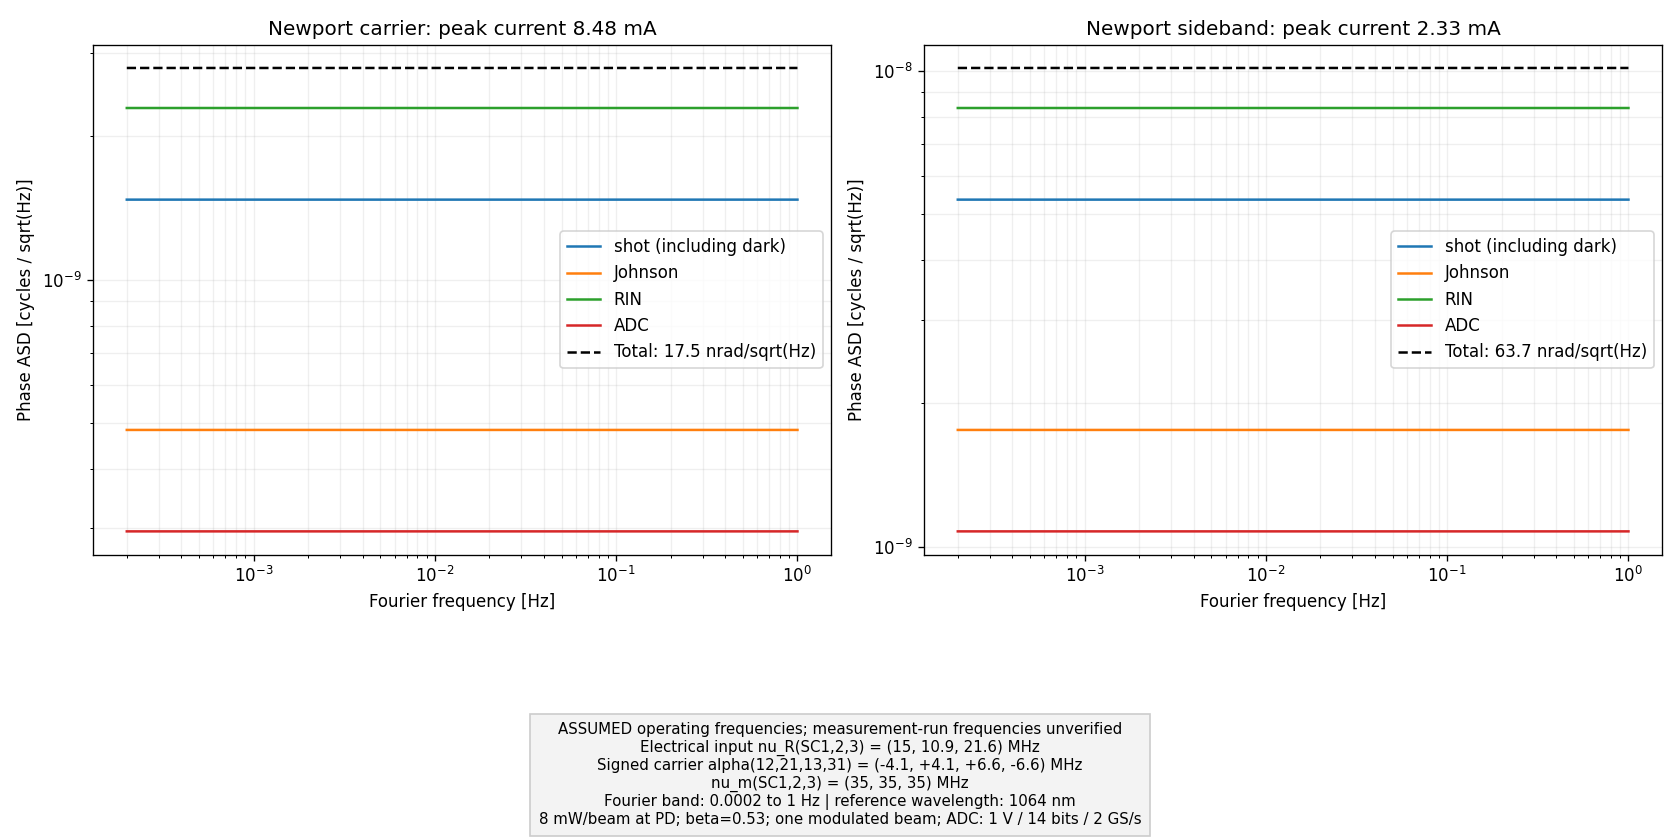

In [5]:
import ast
import scipy.special as special
from scipy.constants import elementary_charge, Boltzmann
NEWPORT_SOURCE=HERE.parent/'PD selection'/'summary.py'
NEWPORT_ENABLED=True
NEWPORT_INCLUDE_ADC=True
NEWPORT_P_SC_W=8e-3       # modulated beam power AT detector, W
NEWPORT_P_REF_W=8e-3      # unmodulated beam power AT detector, W
NEWPORT_MOD_DEPTH=0.53   # radians
NEWPORT_RIN_CORRELATION='fully_correlated' # same conservative sum as old script
newport_parameters=dict(Res=0.6,het_eff=0.9,m=NEWPORT_MOD_DEPTH,T=300,RIN=0.9e-8,
                       R_term=50,I_dark=100e-9,G_total=50,
                       adc_FSR=1,adc_bits=14,adc_fs=2e9)
par=newport_parameters
Jn={channel:abs(special.jv(order,par['m'])) for channel,order in [('carrier',0),('sideband',1)]}
I_beat_unmod_peak=2*par['Res']*np.sqrt(par['het_eff']*NEWPORT_P_SC_W*NEWPORT_P_REF_W)
I_peak={ch:I_beat_unmod_peak*j for ch,j in Jn.items()}
I_dc=par['Res']*(NEWPORT_P_SC_W+NEWPORT_P_REF_W)+par['I_dark']
rin_sum=NEWPORT_P_SC_W+NEWPORT_P_REF_W if NEWPORT_RIN_CORRELATION=='fully_correlated' else np.hypot(NEWPORT_P_SC_W,NEWPORT_P_REF_W)
assert NEWPORT_RIN_CORRELATION in ['fully_correlated','independent']
current_asd={
    'shot (including dark)':np.sqrt(2*elementary_charge*I_dc),
    'Johnson':np.sqrt(4*Boltzmann*par['T']/par['R_term']),
    'RIN':par['Res']*rin_sum*par['RIN'],
    'ADC':(par['adc_FSR']/2**par['adc_bits'])/np.sqrt(6*par['adc_fs'])/par['G_total'],
}
# Distinct carrier and single-sideband ASDs; already in cycles/sqrt(Hz).
newport_asd={ch:{name:np.sqrt(2)*value/(2*np.pi*I_peak[ch]) for name,value in current_asd.items()} for ch in Jn}
newport_included={ch:{k:v for k,v in terms.items() if k!='ADC' or NEWPORT_INCLUDE_ADC} for ch,terms in newport_asd.items()}
newport_total_asd={ch:np.sqrt(sum(v*v for v in terms.values())) for ch,terms in newport_included.items()}
assert np.isclose(newport_total_asd['sideband']/newport_total_asd['carrier'],Jn['carrier']/Jn['sideband'])
assert np.isclose(sum(special.jv(np.arange(-20,21),par['m'])**2),1.0)
assert np.isclose(current_asd['ADC']**2*par['G_total']**2*par['adc_fs']/2,(par['adc_FSR']/2**par['adc_bits'])**2/12)

# Cross-check against original source's sideband calculation with its convention corrected.
source_tree=ast.parse(NEWPORT_SOURCE.read_text(encoding='utf8'))
compute_node=next(node for node in source_tree.body if isinstance(node,ast.FunctionDef) and node.name=='compute')
source_namespace={'np':np,'sp':special,'e':elementary_charge,'kB':Boltzmann}
exec(compile(ast.Module(body=[compute_node],type_ignores=[]),str(NEWPORT_SOURCE),'exec'),source_namespace)
old_values=source_namespace['compute'](NEWPORT_P_SC_W,NEWPORT_P_REF_W,**par)
if NEWPORT_RIN_CORRELATION=='fully_correlated':
    assert np.allclose(list(newport_asd['sideband'].values()),np.array(old_values[:4])/np.sqrt(2),rtol=1e-12,atol=0)

aggregate_vpp_bound=2*I_beat_unmod_peak*par['G_total']
assert aggregate_vpp_bound<par['adc_FSR'], 'Aggregate beat exceeds ADC span; adjust optical power or gain.'
print(f'J0={Jn["carrier"]:.8f}, J1={Jn["sideband"]:.8f}; sideband/carrier ASD ratio={Jn["carrier"]/Jn["sideband"]:.5f}')
print(f'Modulated beam: carrier power={NEWPORT_P_SC_W*Jn["carrier"]**2*1e3:.5g} mW; EACH first sideband={NEWPORT_P_SC_W*Jn["sideband"]**2*1e3:.5g} mW')
print(f'AC aggregate voltage <= {aggregate_vpp_bound:.5g} Vpp; ADC span={par["adc_FSR"]:g} V')
print('component                  carrier [nrad/sqrt Hz]   sideband [nrad/sqrt Hz]')
for name in current_asd:
    print(f'{name:26s} {newport_asd["carrier"][name]*2*np.pi*1e9:15.6g} {newport_asd["sideband"][name]*2*np.pi*1e9:24.6g}')
for ch in Jn: print(f'{ch}: I_peak={I_peak[ch]*1e3:.6g} mA; total ASD={newport_total_asd[ch]:.8g} cycles/sqrt(Hz) = {newport_total_asd[ch]*2*np.pi*1e9:.6g} nrad/sqrt(Hz)')
print('RF carrier / upper sideband / lower sideband magnitudes (MHz) at each PD:')
for i in [1,2,3]: print(i,nu_R[i]/1e6,abs(nu_R[i]+nu_m[i])/1e6,abs(nu_R[i]-nu_m[i])/1e6)
if max(abs(nu_R[i]+nu_m[i]*SCAN_SC1_MODULATION_HZ/nu_m[1]) for i in [1,2,3])>=par['adc_fs']/2:
    print('GHz scan exceeds ADC Nyquist: mathematical fixed-readout extrapolation only.')

def single_link_noise(freq):
    oms=(15e-12/wavelength)*np.sqrt(1+(2e-3/freq)**4)
    acc=(3e-15/((2*np.pi*freq)**2*wavelength))*np.sqrt(1+(.4e-3/freq)**2)*np.sqrt(1+(freq/8e-3)**4)
    return np.sqrt(oms**2+acc**2)

metadata['newport']={'parameters':par,'P_SC_W':NEWPORT_P_SC_W,'P_REF_W':NEWPORT_P_REF_W,
 'enabled':NEWPORT_ENABLED,'include_ADC':NEWPORT_INCLUDE_ADC,'RIN_correlation':NEWPORT_RIN_CORRELATION,
 'power_convention':'incident at PD; one modulated beam and one unmodulated beam',
 'components_cycles_per_sqrt_Hz':newport_asd,'total_cycles_per_sqrt_Hz':newport_total_asd,
 'source_sha256':hashlib.sha256(NEWPORT_SOURCE.read_bytes()).hexdigest()}
metadata['comparison']='existing OMS+acceleration single-link model, independent-equivalent-link propagation'
(OUT/'assumptions.json').write_text(json.dumps(metadata,indent=2))
np.savetxt(OUT/'newport_carrier_sideband.csv',np.array([[newport_asd[ch][name] for ch in Jn] for name in current_asd]+[[newport_total_asd[ch] for ch in Jn]]),delimiter=',',header='carrier_cycles_per_sqrt_Hz,sideband_cycles_per_sqrt_Hz; rows: shot,Johnson,RIN,ADC,total')

fig,axes=plt.subplots(1,2,figsize=(14,7))
for ch,ax in zip(Jn,axes):
    for name,value in newport_asd[ch].items(): ax.loglog(f,np.full_like(f,value),label=name)
    ax.loglog(f,np.full_like(f,newport_total_asd[ch]),'k--',label=f'Total: {newport_total_asd[ch]*2*np.pi*1e9:.3g} nrad/sqrt(Hz)')
    ax.set(xlabel='Fourier frequency [Hz]',ylabel='Phase ASD [cycles / sqrt(Hz)]',title=f'Newport {ch}: peak current {I_peak[ch]*1e3:.3g} mA')
    ax.legend();ax.grid(True,which='both',alpha=.2)
annotate_frequencies(fig,extra=f'8 mW/beam at PD; beta={NEWPORT_MOD_DEPTH}; one modulated beam; ADC: 1 V / 14 bits / 2 GS/s')
fig.savefig(OUT/'newport_readout_components.png',dpi=180)
fig.savefig(OUT/'newport_readout_components.pdf')
plt.show()


Not a complete floor: unresolved calibration, omitted readout/board terms and processing residuals remain explicit.


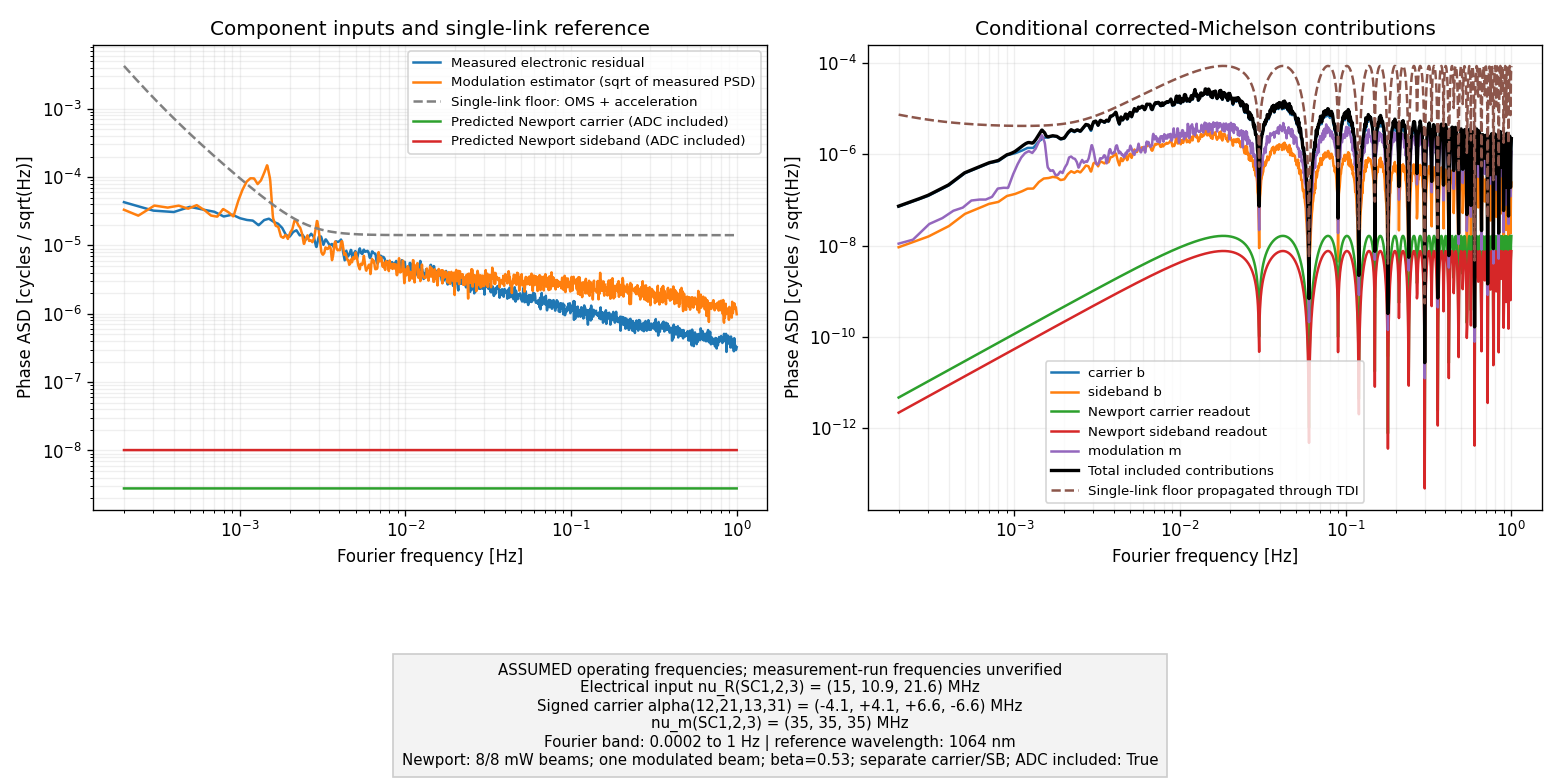

In [6]:
def budget(freq, H, modulation_psd, baseline_psd):
    groups={}
    for label,prefix,extra in [('carrier b','bc',EXTRA_CARRIER_ASD),
                               ('sideband b','bs',EXTRA_SIDEBAND_ASD)]:
        source_psd = baseline_psd.copy() if BASELINE_AS_LINK_PROXY else np.zeros_like(freq)
        if extra is not None: source_psd += float(extra)**2
        if BASELINE_AS_LINK_PROXY or extra is not None:
            groups[label]=sum(np.abs(h)**2*source_psd for n,h in H.items() if n.startswith(prefix))
    if NEWPORT_ENABLED:
        carrier_gain=sum(np.abs(h)**2 for name,h in H.items() if name.startswith('bc'))
        sideband_gain=sum(np.abs(h)**2 for name,h in H.items() if name.startswith('bs'))
        for ch,gain in [('carrier',carrier_gain),('sideband',sideband_gain)]:
            groups['Newport '+ch+' readout']=gain*sum(asd**2 for asd in newport_included[ch].values())
    groups['modulation m']=sum(np.abs(H[f'm{i}'])**2*modulation_psd for i in [1,2,3])
    if BOARD_PSD is not None:
        se=np.broadcast_to(np.asarray(BOARD_PSD(freq),float),freq.shape)
        if np.any(se<0) or not np.all(np.isfinite(se)): raise ValueError('Invalid board PSD')
        groups['board timing']=sum(np.abs(H[f'epsilon{i}'])**2*se for i in [1,2,3])
    return groups

# Recompute transfers here: do not reuse H from an earlier parameter run.
H = transfers(f, modulation=nu_m)
groups=budget(f,H,Sm,Sb)
total=sum(groups.values())
p,_=weights(f)
# Map the recovered single-link reference into the SAME TDI observable.
single_link_asd=single_link_noise(f)
tdi_link_gain=np.sqrt(sum(np.abs(v)**2 for v in p.values()))
allocation=tdi_link_gain*single_link_asd
# This comparison is injected into carrier link phase only; it is not clock-readout noise.
assert np.allclose(allocation**2,sum(np.abs(v)**2*single_link_asd**2 for v in p.values()))
fig,axes=plt.subplots(1,2,figsize=(13,6.5))
axes[0].loglog(f,np.sqrt(Sb),label='Measured electronic residual')
axes[0].loglog(f,np.sqrt(Sm),label='Modulation estimator (sqrt of measured PSD)')
axes[0].loglog(f,single_link_asd,'--',color='gray',label='Single-link floor: OMS + acceleration')
if NEWPORT_ENABLED:
    for ch,value in newport_total_asd.items():
        axes[0].loglog(f,np.full_like(f,value),label='Predicted Newport '+ch+' (ADC included)')
axes[0].set_title('Component inputs and single-link reference')
for name,psd in groups.items(): axes[1].loglog(f,np.sqrt(psd),label=name)
axes[1].loglog(f,np.sqrt(total),'k',lw=2,label='Total included contributions')
axes[1].loglog(f,allocation,'--',label='Single-link floor propagated through TDI')
axes[1].set_title('Conditional corrected-Michelson contributions')
for ax in axes:
    ax.set(xlabel='Fourier frequency [Hz]',ylabel='Phase ASD [cycles / sqrt(Hz)]')
    ax.grid(True,which='both',alpha=.2); ax.legend(fontsize=8)
annotate_frequencies(fig,extra=f'Newport: {NEWPORT_P_SC_W*1e3:g}/{NEWPORT_P_REF_W*1e3:g} mW beams; one modulated beam; beta=0.53; separate carrier/SB; ADC included: {NEWPORT_INCLUDE_ADC}')
fig.savefig(OUT/'conditional_budget.png',dpi=180)
fig.savefig(OUT/'conditional_budget.pdf')
plt.show()
names=list(groups)
np.savetxt(OUT/'conditional_budget.csv',np.column_stack([f]+[np.sqrt(groups[n]) for n in names]+[np.sqrt(total),allocation]),
           delimiter=',',header=','.join(['frequency_Hz']+names+['total_included_ASD','single_link_reference_in_TDI_ASD']))
print('Not a complete floor: unresolved calibration, omitted readout/board terms and processing residuals remain explicit.')


## Check the modulation scaling separately from the total
For fixed beat notes and delays, the correction weights K do not depend on modulation frequency. Scaling all modulation frequencies by s gives
$$H_{m_i}(s\nu^m)=H_{m_i}(\nu^m)/s.$$
Thus the **modulation-only ASD** falls by s for fixed input phase PSD, and remains unchanged for fixed timing noise (whose input phase PSD grows by s squared). The Fourier locations of features/nulls do not shift: those depend on the delays and input spectrum.

The previous scan showed only the **total**, which can mask this change when additive carrier readout noise dominates. Below, the modulation-only and total curves are separate. The component-input modulation curve in the first figure also stays fixed by construction under the fixed-phase assumption.

Both scenarios are normalized to the loaded spectrum at the current nominal nu_m. That nominal point is a provisional normalization, not a verified measurement frequency. Changing it reanchors the fixed-timing scenario; comparisons of a single physical timing-noise model across runs require keeping its measurement-frequency anchor fixed.

After editing frequency settings, run all cells. The budget and scan now explicitly rebuild transfers; previously rerunning the settings and budget while skipping the transfer cell could reuse a stale H with fresh frequency labels.


SC1 MHz | assumption | modulation ASD / nominal modulation ASD
      35 | fixed phase  | 1
      35 | fixed timing | 1
    2000 | fixed phase  | 0.0175
    2000 | fixed timing | 1
Complex-transfer scaling, PSD scaling, and equal-frequency independent derivation passed.


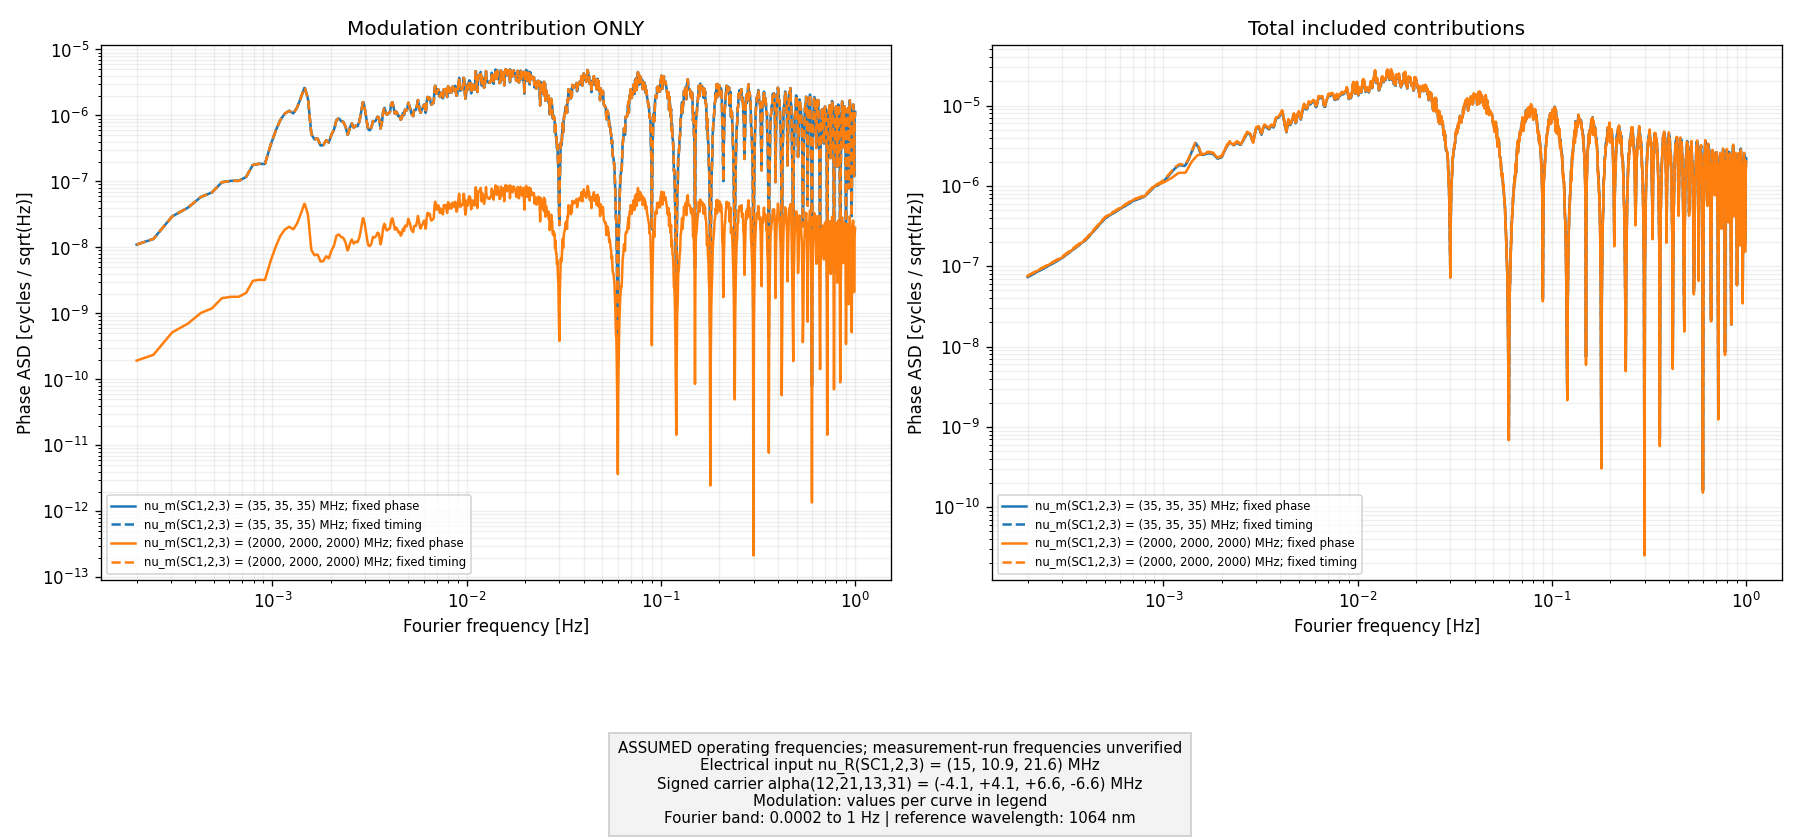

In [7]:
# Rebuild every transfer at the settings used for this comparison.
scales = [1.0, SCAN_SC1_MODULATION_HZ/nu_m[1]]
nominal_H = transfers(f, modulation=nu_m)
nominal_mod_psd = sum(np.abs(nominal_H[f'm{i}'])**2*Sm for i in [1,2,3])
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
rows = []
export_columns = [f]
export_names = ['frequency_Hz']
for index, scale in enumerate(scales):
    scenario_modulation = {i:v*scale for i,v in nu_m.items()}
    hs = transfers(f, modulation=scenario_modulation)
    # Check complex coefficients, including phase, at every Fourier bin.
    for i in [1,2,3]:
        assert np.allclose(scale*hs[f'm{i}'], nominal_H[f'm{i}'], rtol=1e-11, atol=1e-14)
    for scenario, mpsd, style in [('fixed phase',Sm,'-'), ('fixed timing',Sm*scale**2,'--')]:
        g = budget(f, hs, mpsd, Sb)
        mod_asd = np.sqrt(g['modulation m'])
        total_asd = np.sqrt(sum(g.values()))
        expected_psd = nominal_mod_psd/(scale**2) if scenario=='fixed phase' else nominal_mod_psd
        valid = nominal_mod_psd > np.max(nominal_mod_psd)*1e-12
        assert np.allclose(g['modulation m'][valid], expected_psd[valid], rtol=1e-10, atol=0)
        label = f'{modulation_label(scenario_modulation)}; {scenario}'
        for ax,values in zip(axes,[mod_asd,total_asd]):
            ax.loglog(f,values,style,color=f'C{index}',label=label)
        ratio = np.median(mod_asd[valid]/np.sqrt(nominal_mod_psd[valid]))
        rows.append((scenario_modulation[1]/1e6,scenario,ratio))
        export_columns.extend([mod_asd,total_asd])
        export_names.extend([f'{index}_{scenario}_modulation_ASD',f'{index}_{scenario}_total_ASD'])

# Independent algebraic consequence of the article equations for equal nu_m:
# r_mod has exactly the q structure divided by nu_m, so H_mi = sum_j P_ij alpha_ij / nu_m.
if len(set(nu_m.values())) == 1:
    pw,_ = weights(f)
    for i in [1,2,3]:
        expected = sum(pw[l]*alpha[l] for l in links if l[0]==i)/nu_m[i]
        assert np.allclose(nominal_H[f'm{i}'],expected,rtol=1e-10,atol=1e-14)

for ax,title in zip(axes,['Modulation contribution ONLY','Total included contributions']):
    ax.set(xlabel='Fourier frequency [Hz]',ylabel='Phase ASD [cycles / sqrt(Hz)]',title=title)
    ax.grid(True,which='both',alpha=.2); ax.legend(fontsize=7)
annotate_frequencies(fig,scan=True)
fig.savefig(OUT/'modulation_scenarios.png',dpi=180)
fig.savefig(OUT/'modulation_scenarios.pdf')
plt.show()
print('SC1 MHz | assumption | modulation ASD / nominal modulation ASD')
for mhz,scenario,ratio in rows: print(f'{mhz:8g} | {scenario:12s} | {ratio:.8g}')
print('Complex-transfer scaling, PSD scaling, and equal-frequency independent derivation passed.')
np.savetxt(OUT/'modulation_scaling.csv',np.column_stack(export_columns),delimiter=',',header=','.join(export_names))


## Delay-knowledge sensitivity
Here the physical link delays remain unchanged, while the processing delay on link 12 is offset. The transfer matrix includes independent spacecraft laser phases and one shared reference-laser phase. Their illustrative frequency ASDs are 30 Hz/sqrt(Hz), converted to cycles with $1/(2\pi f)$. These are assumptions, not imported measurements.

This is a **one-link processing-error scenario**, not a universal ranging requirement. Laser locking can correlate the spacecraft lasers: replace the independent PSD sum with their physical-source model or spectral covariance when known. Clock residuals also arise for incorrect processing delays and are not included in this laser-only figure.

Conditional linearized crossing over 1â€“30 mHz: 9.489e-08 s.
This depends on the proxy budget, laser assumptions and chosen error pattern; not a measured ranging requirement.


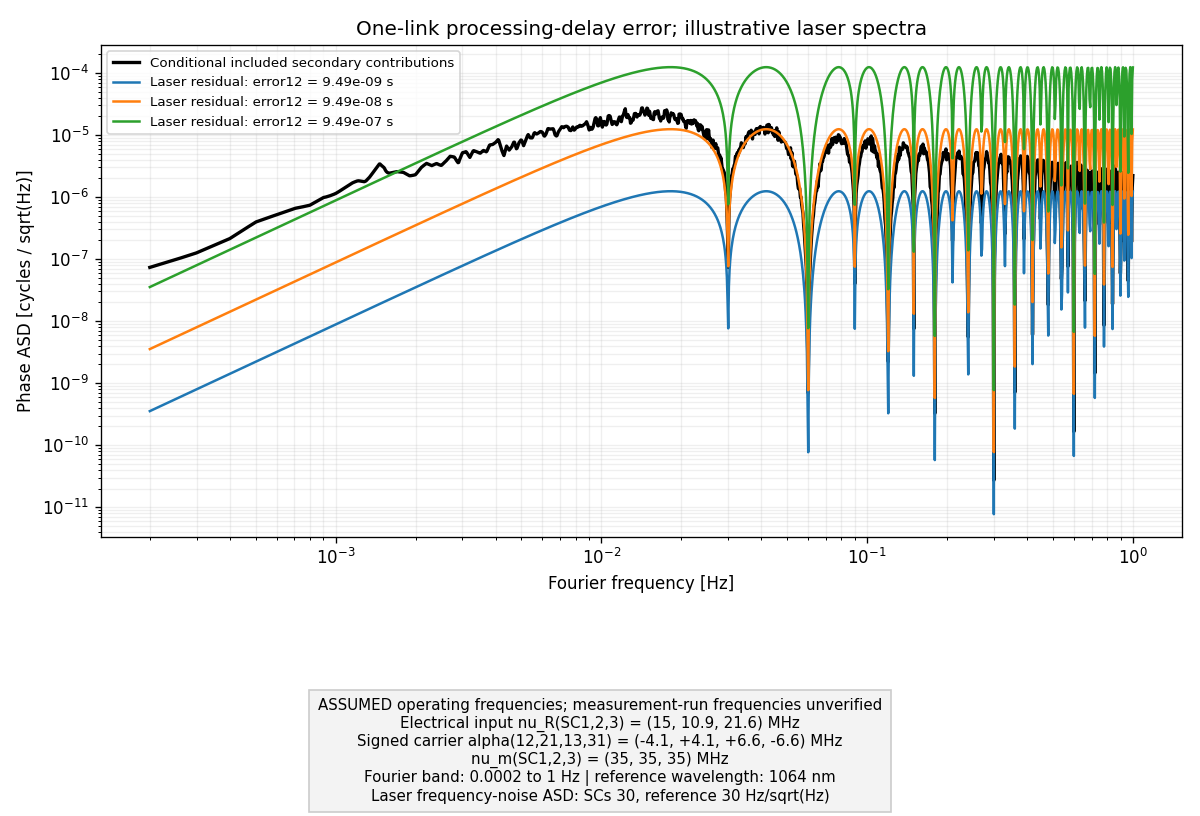

In [8]:
LASER_FREQUENCY_ASD = 30.0
REFERENCE_FREQUENCY_ASD = 30.0
def laser_residual(delta):
    processing=delays.copy()
    processing[1,2]+=delta
    he=transfers(f,processing_delays=processing)
    return sum(np.abs(he[f'phi{i}'])**2 for i in [1,2,3])*(LASER_FREQUENCY_ASD/(2*np.pi*f))**2 + np.abs(he['phi_ref'])**2*(REFERENCE_FREQUENCY_ASD/(2*np.pi*f))**2

# Pick errors around the conditional crossing in a declared band away from transfer nulls.
unit_delta=1e-6
res_unit=laser_residual(unit_delta)
band=(f>=1e-3)&(f<=3e-2)&(allocation>np.max(allocation)*1e-6)&(res_unit>0)
crossing=unit_delta*np.min(np.sqrt(total[band]/res_unit[band]))
assert np.isfinite(crossing) and crossing>0
# Check small-error linearity of ASD where signal is numerically resolved.
r2=laser_residual(2*unit_delta)
assert np.allclose(r2[band],4*res_unit[band],rtol=2e-3,atol=0)
fig,ax=plt.subplots(figsize=(10,6.8))
ax.loglog(f,np.sqrt(total),'k',lw=2,label='Conditional included secondary contributions')
for delta in crossing*np.array([.1,1,10]):
    ax.loglog(f,np.sqrt(laser_residual(delta)),label=f'Laser residual: error12 = {delta:.3g} s')
ax.set(xlabel='Fourier frequency [Hz]',ylabel='Phase ASD [cycles / sqrt(Hz)]',
       title='One-link processing-delay error; illustrative laser spectra')
ax.legend(fontsize=8); ax.grid(True,which='both',alpha=.2)
annotate_frequencies(fig, extra=f'Laser frequency-noise ASD: SCs {LASER_FREQUENCY_ASD:g}, reference {REFERENCE_FREQUENCY_ASD:g} Hz/sqrt(Hz)'); fig.savefig(OUT/'delay_error_scenario.png',dpi=180)
plt.show()
print(f'Conditional linearized crossing over 1â€“30 mHz: {crossing:.4g} s.')
print('This depends on the proxy budget, laser assumptions and chosen error pattern; not a measured ranging requirement.')


## Interpretation and next inputs
The algebraic cancellation and source reuse checks are independent of the provisional PSD interpretation. The numerical curves are conditional on the settings above.

Before using a floor in the article:
1. Trace the modulation CSV to its generating run and confirm measurement modulation frequency, units, reference contribution and estimator readout contamination.
2. Map the processed delay-line residual to the final per-link b terms, including its carrier/sideband operating points.
3. Supply optical and final readout contributions not already contained in the measured inputs; supply a board-jitter bound if relevant.
4. Confirm the simplified reference-modulation model and the actual frequency plan.
5. Replace illustrative laser spectra/independence with the measured locked-laser physical-source model for a quantitative delay requirement.

Exported plots are labelled conditional. The original notebooks and article are unchanged.

## Absolute-scale audit: why can output be below the input?
The measured modulation spectrum and raw X2 output are **different observables**. A small raw X2 ASD alone is not a sensitivity improvement. With equal static delays L and equal modulation frequencies nu_m, independent equal modulation PSDs give
$$A_{X2,m}=G(f)\,C_m\,A_m,$$
$$G(f)=4|\sin(2\pi fL)\sin(4\pi fL)|,$$
$$C_m=\frac{\sqrt{(\alpha_{13}-\alpha_{12})^2+\alpha_{21}^2+\alpha_{31}^2}}{\nu_m}.$$
G contains the Michelson differencing and additional static X2 filtering. At low frequency it is proportional to f squared. Dividing raw X2 by G below removes **only this common equal-arm filter**; it is not strain sensitivity or a full GW-response calibration. For an actual signal comparison the corresponding GW transfer must also be included. Do not compare raw input ASD and X2 ASD as if their responses were identical.

The user has confirmed the current input ASD interpretation. We therefore use the square root of the supplied phase PSD directly, without an additional division by Fourier frequency. The comparison with the original symbolic engine follows below.


Hz | assumed input ASD | frequency-ratio factor | TDI filter | output ASD
0.001 | 5.13502e-05 | 0.377813 | 0.0219126 | 4.25122e-07
0.003 | 1.65748e-05 | 0.377813 | 0.193626 | 1.21252e-06
0.01 | 4.33046e-06 | 0.377813 | 1.73386 | 2.83678e-06
Closed-form absolute gain and independent time-domain modulation injection passed.


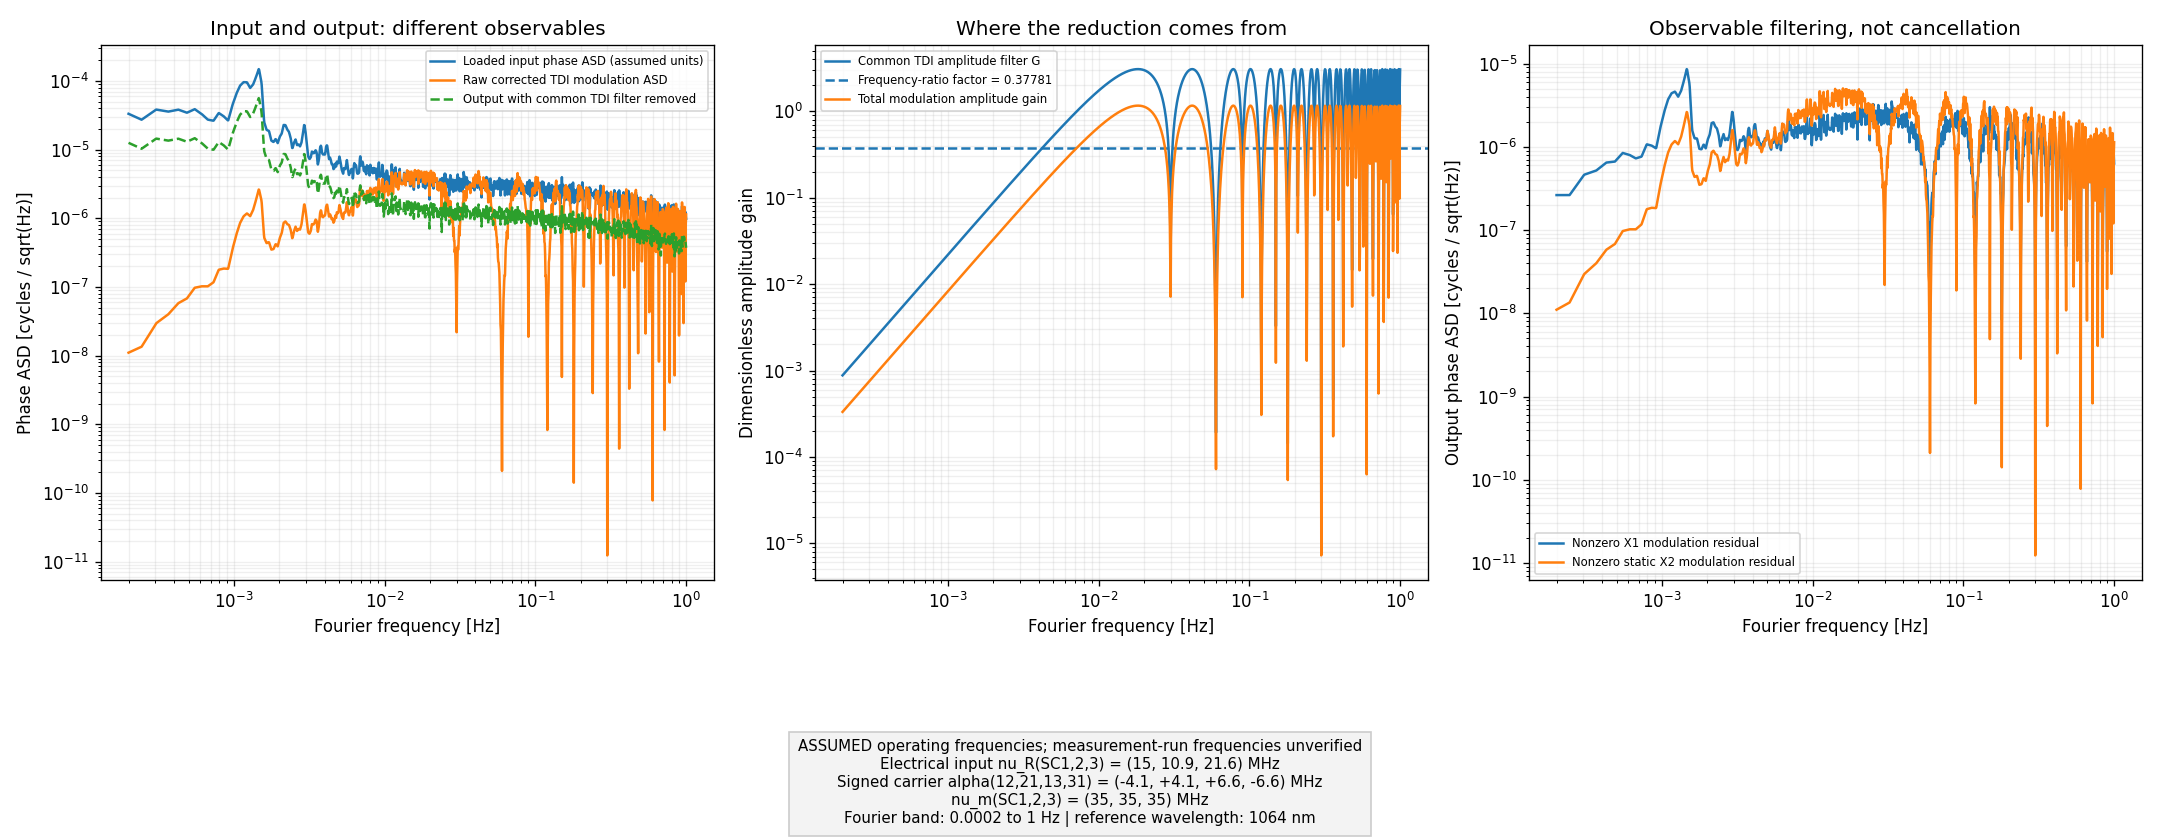

In [9]:
# Independent closed-form absolute normalization, rather than only testing 1/nu scaling.
if len(set(delays.values())) != 1 or len(set(nu_m.values())) != 1:
    print('Equal-arm closed-form audit skipped: settings have unequal delays or modulation frequencies.')
else:
    L = delays[1,2]
    Cm = np.sqrt((alpha[1,3]-alpha[1,2])**2+alpha[2,1]**2+alpha[3,1]**2)/nu_m[1]
    def common_filter(freq):
        g1=2*np.abs(np.sin(2*np.pi*freq*L))
        return g1*2*np.abs(np.sin(4*np.pi*freq*L)) if USE_STATIC_X2 else g1
    audit_H=transfers(f,modulation=nu_m)
    matrix_gain=np.sqrt(sum(np.abs(audit_H[f'm{i}'])**2 for i in [1,2,3]))
    G=common_filter(f)
    valid=G>1e-8
    assert np.allclose(matrix_gain[valid],Cm*G[valid],rtol=1e-10,atol=0)

    # Direct real sinusoid injection into sideband-minus-carrier equations.
    # Delay each source waveform explicitly; apply correction via round-trip sums.
    # This calculation does not call weights() or transfers() to generate its output.
    def direct_modulation_tone(freq,source):
        times=np.arange(4096)/(64*freq)
        def m(i,t): return np.cos(2*np.pi*freq*t) if i==source else np.zeros_like(t)
        def r(i,j,t): return (m(j,t-delays[i,j])-m(i,t))/nu_m[j]
        def rt12(t): return r(1,2,t)+r(2,1,t-delays[1,2])
        def rt13(t): return r(1,3,t)+r(3,1,t-delays[1,3])
        ta=delays[1,2]+delays[2,1]; tb=delays[1,3]+delays[3,1]
        def corrected_x(t):
            return (-alpha[1,3]*rt12(t)-alpha[3,1]*rt12(t-tb)
                    +alpha[1,2]*rt13(t)+alpha[2,1]*rt13(t-ta)
                    +alpha[2,1]*(r(2,1,t-delays[1,2])-r(2,1,t-delays[1,2]-tb))
                    -alpha[3,1]*(r(3,1,t-delays[1,3])-r(3,1,t-delays[1,3]-ta)))
        y=corrected_x(times)
        if USE_STATIC_X2: y=y-corrected_x(times-ta-tb)
        # Complex coefficient fitted over exactly 64 cycles.
        return 2*np.mean(y*np.exp(-2j*np.pi*freq*times))
    for freq in [.001,.003,.01]:
        hs=transfers(np.array([freq]),modulation=nu_m)
        for source in [1,2,3]:
            assert np.allclose(direct_modulation_tone(freq,source),hs[f'm{source}'][0],rtol=1e-9,atol=1e-12)

    sample_f=np.array([.001,.003,.01])
    sample_input=np.sqrt(interpolate_psd(sample_f,fm,sm))
    sample_G=common_filter(sample_f)
    table=np.column_stack([sample_f,sample_input,np.full(3,Cm),sample_G,sample_input*Cm*sample_G])
    print('Hz | assumed input ASD | frequency-ratio factor | TDI filter | output ASD')
    for row in table: print(' | '.join(f'{v:.6g}' for v in row))
    print('Closed-form absolute gain and independent time-domain modulation injection passed.')
    np.savetxt(OUT/'absolute_scale_audit.csv',table,delimiter=',',header='Hz,input_ASD,Cm,TDI_filter,output_ASD')

    raw_f,raw_psd=load_spectrum(HERE/'modulator_psd.csv',1)
    phase_reading=np.sqrt(interpolate_psd(f,raw_f,raw_psd))
    fig,axes=plt.subplots(1,3,figsize=(18,7))
    axes[0].loglog(f,np.sqrt(Sm),label='Loaded input phase ASD (assumed units)')
    axes[0].loglog(f,np.sqrt(Sm)*matrix_gain,label='Raw corrected TDI modulation ASD')
    axes[0].loglog(f,np.sqrt(Sm)*Cm,'--',label='Output with common TDI filter removed')
    axes[0].set_title('Input and output: different observables')
    axes[0].set_ylabel('Phase ASD [cycles / sqrt(Hz)]')
    axes[1].loglog(f,G,label='Common TDI amplitude filter G')
    axes[1].axhline(Cm,ls='--',label=f'Frequency-ratio factor = {Cm:.5g}')
    axes[1].loglog(f,matrix_gain,label='Total modulation amplitude gain')
    axes[1].set_title('Where the reduction comes from')
    axes[1].set_ylabel('Dimensionless amplitude gain')
    x1h=transfers(f,modulation=nu_m,x2=False)
    x2h=transfers(f,modulation=nu_m,x2=True)
    axes[2].loglog(f,phase_reading*np.sqrt(sum(abs(x1h[f'm{i}'])**2 for i in [1,2,3])),label='Nonzero X1 modulation residual')
    axes[2].loglog(f,phase_reading*np.sqrt(sum(abs(x2h[f'm{i}'])**2 for i in [1,2,3])),label='Nonzero static X2 modulation residual')
    axes[2].set_title('Observable filtering, not cancellation')
    axes[2].set_ylabel('Output phase ASD [cycles / sqrt(Hz)]')
    for ax in axes:
        ax.set_xlabel('Fourier frequency [Hz]'); ax.legend(fontsize=7); ax.grid(True,which='both',alpha=.2)
    annotate_frequencies(fig)
    fig.savefig(OUT/'absolute_scale_audit.png',dpi=180)
    fig.savefig(OUT/'absolute_scale_audit.pdf')
    plt.show()


## Comparison with your original TDI and clock-correction code
This cell imports **plotting/tdi_core.py** and calls its own symbolic measurement builder, corrected-TDI builder and transfer-function extractor. It does not reimplement them. Their TDI/correction/extractor function bodies are also checked against plottingX2.py.

For this comparison only, arm rates are zero, consistent with the new notebook. Both implementations use identical input phase PSDs, nominal frequencies, and static delays. Angular-frequency symbols in the old code receive 2*pi*nu; their ratios therefore contain no extra 2*pi conversion. Its old plotting-layer division of the measured PSD by f squared is deliberately not applied to the confirmed phase PSD.

The original modulation sideband term is local-minus-delayed-remote; the article uses delayed-remote-minus-local. The plot compares ASDs (independent of this source sign). Complex coefficients are compared with their matching source signs. X1 also has an observable-sign convention difference; the net mapping is checked numerically rather than assumed from labels.

The comparison includes the nominal configuration and unequal static delays. A clock-only check uses the original X2 builder. Modulation is **not cancelled**: its finite residual enters through clock correction, with the frequency and delay transfer functions shown above.


Original engine and plottingX2.py have identical TDI, correction and extractor functions.
Original static X2: clock-only expression is exactly zero.
X1, m1: max absolute complex error after sign mapping = 7.87e-16
X1, m2: max absolute complex error after sign mapping = 2.67e-15
X1, m3: max absolute complex error after sign mapping = 3.98e-15
X2, m1: max absolute complex error after sign mapping = 1.34e-14
X2, m2: max absolute complex error after sign mapping = 6.82e-15
X2, m3: max absolute complex error after sign mapping = 1.11e-14
Unequal-static-delay cross-check also passed for X1 and X2.


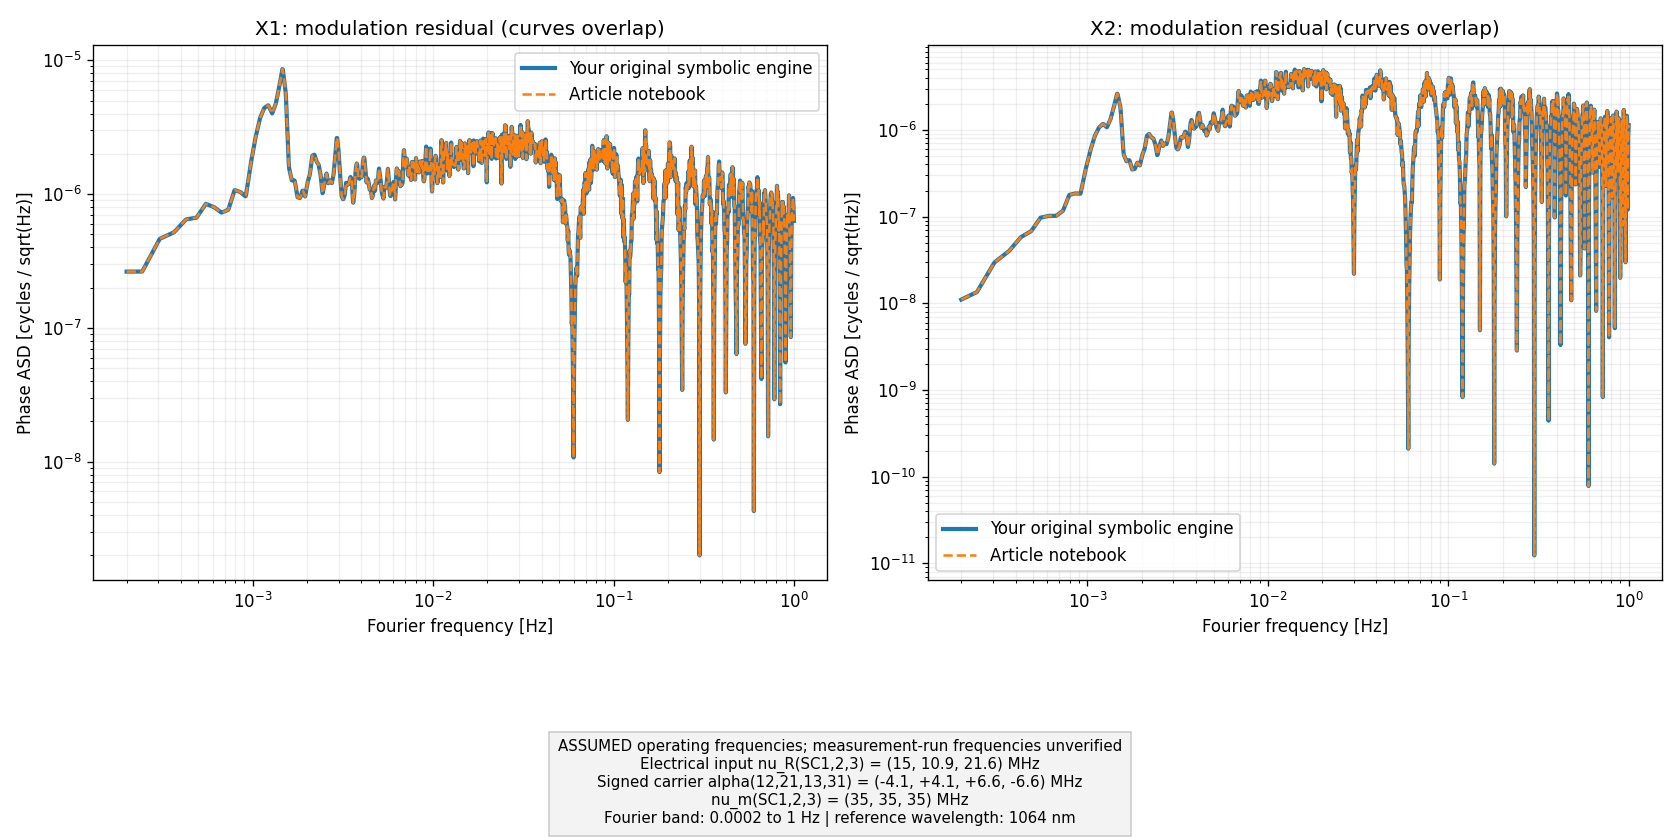

In [10]:
import importlib.util, ast
original_path=HERE/'plotting'/'tdi_core.py'
spec=importlib.util.spec_from_file_location('original_tdi_audit',original_path)
original=importlib.util.module_from_spec(spec)
spec.loader.exec_module(original)
# Isolated module instance: no edits to your script and no changes to the notebook delays.
original.dtau={l:sp.Integer(0) for l in original.dtau}
old_ast=ast.parse(original_path.read_text(encoding='utf8'))
plot_ast=ast.parse((HERE/'plotting'/'plottingX2.py').read_text(encoding='utf8'))
for name in ['build_corrected_tdi','build_tdi_from_eta','get_transfer_function']:
    def body(tree): return next(node for node in tree.body if isinstance(node,ast.FunctionDef) and node.name==name)
    assert ast.dump(body(old_ast),include_attributes=False)==ast.dump(body(plot_ast),include_attributes=False)
print('Original engine and plottingX2.py have identical TDI, correction and extractor functions.')

old_expr={name:original.build_corrected_tdi('modulation',name) for name in ['X1','X2']}
old_tf={name:[original.get_transfer_function(old_expr[name],fn) for fn in [original.N1_m,original.N2_m,original.N3_m]] for name in old_expr}
assert sp.expand(original.build_corrected_tdi('clock','X2'))==0
print('Original static X2: clock-only expression is exactly zero.')

def original_modulation_transfers(freq,kind):
    values={original.omega1:2*np.pi*nu_R[1],original.omega2:2*np.pi*nu_R[2],original.omega3:2*np.pi*nu_R[3],
            original.omega1m:2*np.pi*nu_m[1],original.omega2m:2*np.pi*nu_m[2],original.omega3m:2*np.pi*nu_m[3]}
    values.update({symbol:delays.get(link,8.3) for link,symbol in original.tau.items()})
    return [np.broadcast_to(np.asarray(sp.lambdify(original.omega_sym,tf.subs(values),'numpy')(2*np.pi*freq),complex),freq.shape) for tf in old_tf[kind]]

fig,axes=plt.subplots(1,2,figsize=(14,7))
comparison=[]
for kind,ax in zip(['X1','X2'],axes):
    ho=original_modulation_transfers(f,kind)
    hn=transfers(f,modulation=nu_m,x2=kind=='X2')
    for i,v in enumerate(ho,1):
        expected=hn[f'm{i}']
        mask=np.abs(expected)>np.max(np.abs(expected))*1e-7
        assert np.allclose(v[mask],-expected[mask],rtol=1e-7,atol=1e-12)
        print(f'{kind}, m{i}: max absolute complex error after sign mapping = {np.max(abs(v+expected)):.3g}')
    old_asd=np.sqrt(sum(abs(v)**2 for v in ho)*Sm)
    new_asd=np.sqrt(sum(abs(hn[f'm{i}'])**2 for i in [1,2,3])*Sm)
    ax.loglog(f,old_asd,label='Your original symbolic engine',lw=2.5)
    ax.loglog(f,new_asd,'--',label='Article notebook',lw=1.5)
    ax.set(title=f'{kind}: modulation residual (curves overlap)',xlabel='Fourier frequency [Hz]',ylabel='Phase ASD [cycles / sqrt(Hz)]')
    ax.legend();ax.grid(True,which='both',alpha=.2)
    comparison.extend([old_asd,new_asd])
annotate_frequencies(fig)
fig.savefig(OUT/'original_script_comparison.png',dpi=180)
fig.savefig(OUT/'original_script_comparison.pdf')
plt.show()
np.savetxt(OUT/'original_script_comparison.csv',np.column_stack([f]+comparison),delimiter=',',header='Hz,original_X1,new_X1,original_X2,new_X2')

saved_delays=delays.copy()
try:
    delays={l:v for l,v in zip(links,[7.9,8.1,8.3,8.5])}
    for kind in ['X1','X2']:
        ho=original_modulation_transfers(f,kind)
        hn=transfers(f,modulation=nu_m,x2=kind=='X2')
        for i,v in enumerate(ho,1):
            assert np.allclose(v,-hn[f'm{i}'],rtol=1e-7,atol=1e-11)
    print('Unequal-static-delay cross-check also passed for X1 and X2.')
finally:
    delays=saved_delays
